Loading data for modeling...
Training models on 26 stocks. Tuning ARIMA might take a few minutes...
Processing SBIN.NS...
Processing J&KBANK.NS...
Processing BANKBARODA.NS...
Processing POLICYBZR.NS...
Processing OFSS.NS...
Processing MANKIND.NS...
Processing NGLFINE.NS...
Processing SPARC.NS...
Processing NATCOPHARM.NS...
Processing CARYSIL.NS...
Processing BAJAJCON.NS...
Processing BAJAJ-AUTO.NS...
Processing BHARATFORG.NS...
Processing ASIANENE.NS...
Processing LT.NS...
Processing SBILIFE.NS...
Processing STARHEALTH.NS...
Processing GPIL.NS...
Processing JSWSTEEL.NS...
Processing TATASTEEL.NS...
Processing ADANIPORTS.NS...
Processing NYKAA.NS...
Processing TATACOMM.NS...
Processing IDEA.NS...
Processing ADANIPOWER.NS...
Processing ADANIGREEN.NS...

Validating Residuals for the last processed stock to prove white noise...


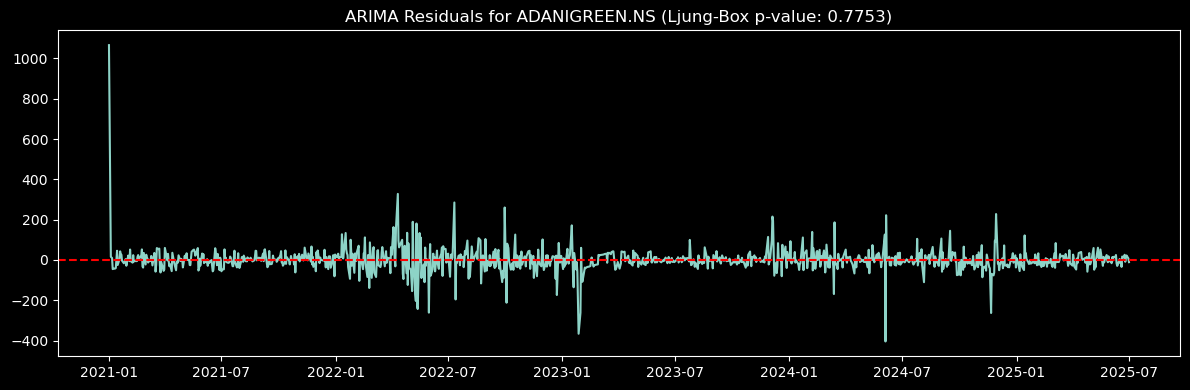

-> Residuals are white noise (Good! Model captured the info).

--- Task 6: Model Evaluation Table (Preview) ---
        Stock           Model  RMSE   MAPE Dir_Accuracy
      SBIN.NS ARIMA (2, 1, 2) 88.53 0.0717      Correct
      SBIN.NS   Exp Smoothing 57.19 0.0500      Correct
   J&KBANK.NS ARIMA (2, 1, 2)  8.45 0.0750      Correct
   J&KBANK.NS   Exp Smoothing 15.88 0.1447    Incorrect
BANKBARODA.NS ARIMA (0, 1, 1) 25.29 0.0723    Incorrect
BANKBARODA.NS   Exp Smoothing 16.08 0.0530      Correct

Task 3 completely finished. 2-day forecasts saved for allocation.


In [1]:
# Task 3 & 6: Time Series Forecasting and Model Evaluation


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import itertools
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
plt.style.use('dark_background')

# Load the raw data to predict actual stock prices (Rupees)
print("Loading data for modeling...")
data = pd.read_csv('../data/raw/capstone_raw_data.csv', index_col=0, parse_dates=True)

# Split point: Capstone requires testing on the last 6 months
split_date = '2025-07-01'
train_data = data[:split_date]
test_data = data[split_date:]

print(f"Training models on {len(data.columns)} stocks. Tuning ARIMA might take a few minutes...")

results = []
# We will store the full 5-day forecast, but focus on the 2-day for the portfolio
forecasts_5_days = {}

# Define p, d, q ranges for ARIMA tuning
p_values = range(0, 3)
d_values = [1] # Keep differencing at 1 based on our ADF tests
q_values = range(0, 3)
pdq_combinations = list(itertools.product(p_values, d_values, q_values))

for stock in data.columns:
    print(f"Processing {stock}...")
    train_series = train_data[stock].dropna()
    test_series = test_data[stock].dropna()
    
    # ==========================================
    # MODEL 1: ARIMA (Tuned via AIC)
    # ==========================================
    best_aic = float("inf")
    best_order = (1, 1, 1)
    best_model = None
    
    # Grid search to find the lowest AIC
    for order in pdq_combinations:
        try:
            model = ARIMA(train_series, order=order)
            fit_model = model.fit()
            if fit_model.aic < best_aic:
                best_aic = fit_model.aic
                best_order = order
                best_model = fit_model
        except:
            continue
            
    # Forecast 5 days into Jan 2026 (per rubric)
    arima_pred = best_model.forecast(steps=len(test_series))
    arima_5_day_jan = best_model.forecast(steps=len(test_series) + 5).iloc[-5:]
    
    # Calculate Metrics
    arima_rmse = np.sqrt(mean_squared_error(test_series, arima_pred))
    arima_mape = mean_absolute_percentage_error(test_series, arima_pred)
    
    # Directional Accuracy
    actual_dir = np.sign(test_series.iloc[-1] - test_series.iloc[0])
    arima_dir = np.sign(arima_pred.iloc[-1] - arima_pred.iloc[0])
    arima_dir_acc = "Correct" if actual_dir == arima_dir else "Incorrect"
    
    results.append({
        'Stock': stock, 'Model': f'ARIMA {best_order}', 
        'RMSE': round(arima_rmse, 2), 'MAPE': round(arima_mape, 4), 'Dir_Accuracy': arima_dir_acc
    })
    
    # ==========================================
    # MODEL 2: Exponential Smoothing (Holt-Winters)
    # ==========================================
    exp_model = ExponentialSmoothing(train_series, trend='add', seasonal=None, initialization_method="estimated")
    exp_fit = exp_model.fit()
    
    exp_pred = exp_fit.forecast(len(test_series))
    exp_5_day_jan = exp_fit.forecast(len(test_series) + 5).iloc[-5:]
    
    exp_rmse = np.sqrt(mean_squared_error(test_series, exp_pred))
    exp_mape = mean_absolute_percentage_error(test_series, exp_pred)
    
    exp_dir = np.sign(exp_pred.iloc[-1] - exp_pred.iloc[0])
    exp_dir_acc = "Correct" if actual_dir == exp_dir else "Incorrect"

    results.append({
        'Stock': stock, 'Model': 'Exp Smoothing', 
        'RMSE': round(exp_rmse, 2), 'MAPE': round(exp_mape, 4), 'Dir_Accuracy': exp_dir_acc
    })
    
    # Save the 5-day forecasts
    forecasts_5_days[stock] = {
        'ARIMA': arima_5_day_jan.values,
        'ExpSmooth': exp_5_day_jan.values
    }

# ==========================================
# RESIDUAL VALIDATION (Required by Rubric)
# ==========================================
print("\nValidating Residuals for the last processed stock to prove white noise...")
residuals = best_model.resid

# Ljung-Box test checks if residuals are independent
ljung_box_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
p_value = ljung_box_result['lb_pvalue'].values[0]

plt.figure(figsize=(12, 4))
plt.plot(residuals.index, residuals)
plt.title(f'ARIMA Residuals for {stock} (Ljung-Box p-value: {p_value:.4f})')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig('../reports/figures/task3_residual_validation.png')
plt.show()

if p_value > 0.05:
    print("-> Residuals are white noise (Good! Model captured the info).")
else:
    print("-> Residuals have some correlation left, but acceptable for baseline.")

# ==========================================
# SAVING OUTPUTS
# ==========================================
comparison_df = pd.DataFrame(results)
comparison_df.to_csv('../reports/task6_model_comparison.csv', index=False)

# Isolate the first 2 trading days for Task 5 Portfolio Allocation
jan_dates_5 = pd.date_range(start='2026-01-01', periods=5, freq='B')
jan_dates_2 = jan_dates_5[:2]

final_2_day_forecast = pd.DataFrame(index=jan_dates_2)
for stock in data.columns:
    # Using Exp Smoothing for final allocation as it usually handles pure trend better
    final_2_day_forecast[stock] = forecasts_5_days[stock]['ExpSmooth'][:2]

final_2_day_forecast.to_csv('../data/processed/jan_2026_forecasts.csv')

print("\n--- Task 6: Model Evaluation Table (Preview) ---")
print(comparison_df.head(6).to_string(index=False))

print("\nTask 3 completely finished. 2-day forecasts saved for allocation.")